# Mini-Challenge 2: Sentiment Analysis

This notebook consolidates the entire project, keeping helper files inline except `models.py` which is needed externally for Apple Silicon performance optimization.

In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["MPLCONFIGDIR"] = os.path.abspath(".matplotlib")
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

%matplotlib inline
import logging
import sys
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from datasets import load_dataset
from dotenv import load_dotenv
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

load_dotenv()

True

In [3]:
def load_and_split_data(
    dataset_name: str = "takala/financial_phrasebank",
    config_name: str = "sentences_allagree",  # sentences_75agree, sentences_66agree, sentences_50agree
    seed: int = 42,
    test_size: float = 0.2,
    val_size: float = 0.1,  # Fraction of the remaining train data
    train_sizes: List[int] = [100, 250, 500, 1000],
) -> Dict[str, pd.DataFrame]:
    """
    Loads the Financial Phrasebank dataset and creates hierarchically nested splits.

    Args:
        dataset_name: Hugging Face dataset name.
        config_name: Dataset configuration (e.g., 'sentences_allagree').
        seed: Random seed for reproducibility.
        test_size: Fraction of data for the test set.
        val_size: Fraction of the *remaining* data for the validation set.
        train_sizes: List of sizes for the hierarchical training sets.

    Returns:
        A dictionary containing:
        - 'test': Test DataFrame
        - 'val': Validation DataFrame
        - 'train_{size}': Training DataFrame for each size in train_sizes
        - 'unlabeled_{size}': Unlabeled DataFrame for each size (remainder of train pool)
    """

    # Load dataset
    # Load dataset
    print(f"Loading dataset: {dataset_name} ({config_name})")
    if config_name:
        dataset = load_dataset(dataset_name, config_name, split="train")
    else:
        dataset = load_dataset(dataset_name, split="train")

    # Check for nested structure (specific to descartes100/enhanced-financial-phrasebank)
    if "train" in dataset.column_names and len(dataset.column_names) == 1:
        print("Detected nested dataset structure. Flattening...")
        dataset = dataset.map(lambda x: x["train"], remove_columns=["train"])

    df = dataset.to_pandas()

    # Initial Split: Train+Val vs Test
    train_val_df, test_df = train_test_split(
        df, test_size=test_size, random_state=seed, stratify=df["label"]
    )

    # Split Train+Val into Train_Pool and Val
    train_pool_df, val_df = train_test_split(
        train_val_df,
        test_size=val_size,
        random_state=seed,
        stratify=train_val_df["label"],
    )

    print(f"Total samples: {len(df)}")
    print(f"Test size: {len(test_df)}")
    print(f"Validation size: {len(val_df)}")
    print(f"Training pool size: {len(train_pool_df)}")

    splits = {"test": test_df, "val": val_df}

    # Create Hierarchical Splits
    # We want train_100 subset of train_250 subset of train_500 ...
    # To do this, we can shuffle the pool once and take the first N samples.

    shuffled_pool = train_pool_df.sample(frac=1, random_state=seed).reset_index(
        drop=True
    )

    for size in train_sizes:
        if size > len(shuffled_pool):
            raise ValueError(
                f"Requested training size {size} is larger than available pool {len(shuffled_pool)}"
            )

        # Select the first 'size' samples as the labeled training set
        train_subset = shuffled_pool.iloc[:size].copy()

        # The rest are considered 'unlabeled' for this scenario
        unlabeled_subset = shuffled_pool.iloc[size:].copy()
        # Remove the label column from unlabeled set to simulate reality (optional, but good practice)
        # unlabeled_subset = unlabeled_subset.drop(columns=['label'])

        splits[f"train_{size}"] = train_subset
        splits[f"unlabeled_{size}"] = unlabeled_subset

        print(f"Created split 'train_{size}': {len(train_subset)} samples")
        print(f"Created split 'unlabeled_{size}': {len(unlabeled_subset)} samples")

    return splits

In [4]:
class WeakLabeler:
    def __init__(self, model_name: str = "all-mpnet-base-v2"):
        self.model = SentenceTransformer(model_name)

    def encode(self, sentences: List[str]) -> np.ndarray:
        return self.model.encode(sentences, show_progress_bar=True)

    def train_knn(
        self, train_df: pd.DataFrame, n_neighbors: int = 5
    ) -> KNeighborsClassifier:
        """
        Trains a k-NN classifier on the labeled training data embeddings.
        """
        embeddings = self.encode(train_df["sentence"].tolist())
        labels = train_df["label"].tolist()

        knn = KNeighborsClassifier(n_neighbors=n_neighbors)
        knn.fit(embeddings, labels)
        return knn

    def predict(
        self, knn: KNeighborsClassifier, unlabeled_df: pd.DataFrame
    ) -> pd.DataFrame:
        """
        Predicts labels for unlabeled data using the trained k-NN.
        Returns the unlabeled dataframe with a new 'weak_label' column.
        """
        sentences = unlabeled_df["sentence"].tolist()
        embeddings = self.encode(sentences)

        weak_labels = knn.predict(embeddings)

        result_df = unlabeled_df.copy()
        result_df["label"] = (
            weak_labels  # Assign weak labels to 'label' column for compatibility
        )
        result_df["is_weak"] = True

        return result_df

# Data Preparation

This notebook uses the **Financial PhraseBank** dataset, a polar sentiment corpus of 4,840 short sentences drawn from English-language financial news. Each sentence is labeled Positive, Negative, or Neutral, and the dataset is partitioned by how strongly 5–8 annotators agreed on the label (multiple agreement-level subsets are provided).  ￼

Annotations were made from an investor’s point of view—i.e., labels reflect whether the news would be expected to move a stock’s price up, down, or neither. This framing makes the dataset especially well-suited for finance-aware sentiment models and downstream tasks like event or headline screening.  ￼

In the cells below, we’ll load the dataset from Hugging Face and create hierarchically nested splits for the sentiment analysis mini-challenge.

## Load Data and Create Splits

We use the `load_and_split_data` function defined in this notebook.

In [5]:
splits = load_and_split_data()

print("Available splits:", splits.keys())

Loading dataset: takala/financial_phrasebank (sentences_allagree)


README.md: 0.00B [00:00, ?B/s]

Using the latest cached version of the dataset since takala/financial_phrasebank couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'sentences_allagree' at /Users/stefanbinkert/.cache/huggingface/datasets/takala___financial_phrasebank/sentences_allagree/1.0.0/550bde12e6c30e2674da973a55f57edde5181d53f5a5a34c1531c53f93b7e141 (last modified on Tue Nov 25 21:04:35 2025).


Total samples: 2264
Test size: 453
Validation size: 182
Training pool size: 1629
Created split 'train_100': 100 samples
Created split 'unlabeled_100': 1529 samples
Created split 'train_250': 250 samples
Created split 'unlabeled_250': 1379 samples
Created split 'train_500': 500 samples
Created split 'unlabeled_500': 1129 samples
Created split 'train_1000': 1000 samples
Created split 'unlabeled_1000': 629 samples
Available splits: dict_keys(['test', 'val', 'train_100', 'unlabeled_100', 'train_250', 'unlabeled_250', 'train_500', 'unlabeled_500', 'train_1000', 'unlabeled_1000'])


## Verify Hierarchical Property

Ensure that `train_100` is a subset of `train_250`, which is a subset of `train_500`, and so on.

In [6]:
train_100 = splits["train_100"]
train_250 = splits["train_250"]
train_500 = splits["train_500"]
train_1000 = splits["train_1000"]

# Check if indices of smaller sets are contained in larger sets
assert set(train_100.index).issubset(set(train_250.index))
assert set(train_250.index).issubset(set(train_500.index))
assert set(train_500.index).issubset(set(train_1000.index))

print("Hierarchical property verified!")

Hierarchical property verified!


## Visualize Class Distribution

Let's look at the distribution of labels (0: negative, 1: neutral, 2: positive) in the training sets.

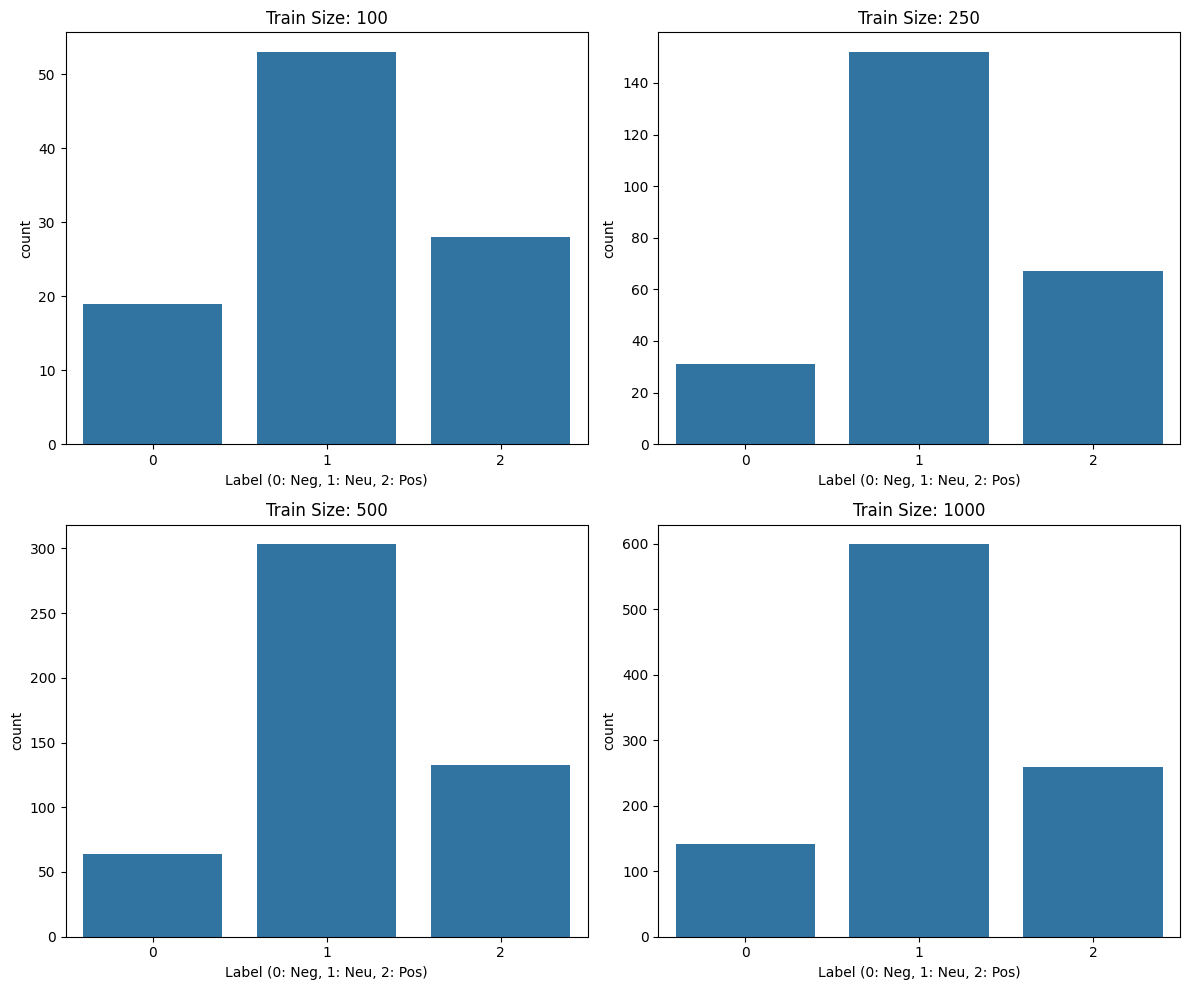

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, size in enumerate([100, 250, 500, 1000]):
    df = splits[f"train_{size}"]
    sns.countplot(x="label", data=df, ax=axes[i])
    axes[i].set_title(f"Train Size: {size}")
    axes[i].set_xlabel("Label (0: Neg, 1: Neu, 2: Pos)")

plt.tight_layout()
plt.show()

# Baseline Model Training

This notebook trains a baseline sentiment classifier (DistilBERT) on hierarchically nested training sets (100, 250, 500, 1000 samples) and evaluates its performance.

In [8]:
from transformers import logging as transformers_logging
from models import SentimentClassifier

# Suppress tokenizer parallelism warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Suppress transformers initialization warnings
transformers_logging.set_verbosity_error()



## Train and Evaluate on Different Sizes

We will train a separate model for each training set size and record the test accuracy and F1 score.

In [10]:
train_sizes = [100, 250, 500, 1000]
results = []

for size in train_sizes:
    print(f"\n=== Training on {size} samples ===")
    train_df = splits[f"train_{size}"]

    # Initialize model
    classifier = SentimentClassifier(
        model_name="distilbert-base-uncased", output_dir=f"models/baseline_{size}"
    )

    # Train
    classifier.train(train_df, val_df, epochs=3, batch_size=16)

    # Evaluate
    metrics = classifier.evaluate(test_df)
    print(f"Results for {size}: {metrics}")

    results.append(
        {
            "train_size": size,
            "accuracy": metrics["eval_accuracy"],
            "f1": metrics["eval_f1"],
        }
    )


=== Training on 100 samples ===


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/182 [00:00<?, ? examples/s]

Using device: mps
{'eval_loss': 0.9817848801612854, 'eval_accuracy': 0.6153846153846154, 'eval_f1': 0.25396825396825395, 'eval_precision': 0.20512820512820515, 'eval_recall': 0.3333333333333333, 'eval_runtime': 62.1183, 'eval_samples_per_second': 2.93, 'eval_steps_per_second': 0.193, 'epoch': 1.0}
{'loss': 1.0344, 'grad_norm': 1.4566487073898315, 'learning_rate': 1.1428571428571429e-05, 'epoch': 1.4285714285714286}
{'eval_loss': 0.9406060576438904, 'eval_accuracy': 0.6538461538461539, 'eval_f1': 0.3448137201680841, 'eval_precision': 0.4003944773175543, 'eval_recall': 0.38405797101449274, 'eval_runtime': 62.5116, 'eval_samples_per_second': 2.911, 'eval_steps_per_second': 0.192, 'epoch': 2.0}
{'loss': 0.9568, 'grad_norm': 2.2420437335968018, 'learning_rate': 1.904761904761905e-06, 'epoch': 2.857142857142857}
{'eval_loss': 0.921984851360321, 'eval_accuracy': 0.6703296703296703, 'eval_f1': 0.37407925407925413, 'eval_precision': 0.404477451296954, 'eval_recall': 0.4057971014492754, 'eval_ru

Map:   0%|          | 0/453 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/182 [00:00<?, ? examples/s]

Using device: mps
{'loss': 1.0177, 'grad_norm': 2.753700017929077, 'learning_rate': 1.904761904761905e-05, 'epoch': 0.15873015873015872}
{'loss': 0.9194, 'grad_norm': 2.3035318851470947, 'learning_rate': 1.798941798941799e-05, 'epoch': 0.31746031746031744}
{'loss': 0.7565, 'grad_norm': 2.3694705963134766, 'learning_rate': 1.693121693121693e-05, 'epoch': 0.47619047619047616}
{'loss': 0.6034, 'grad_norm': 2.8529465198516846, 'learning_rate': 1.5873015873015872e-05, 'epoch': 0.6349206349206349}
{'loss': 0.6036, 'grad_norm': 3.7405223846435547, 'learning_rate': 1.4814814814814815e-05, 'epoch': 0.7936507936507936}
{'loss': 0.5252, 'grad_norm': 3.5974442958831787, 'learning_rate': 1.3756613756613758e-05, 'epoch': 0.9523809523809523}
{'eval_loss': 0.40479516983032227, 'eval_accuracy': 0.8571428571428571, 'eval_f1': 0.7637034707480498, 'eval_precision': 0.8711304347826087, 'eval_recall': 0.7252415458937197, 'eval_runtime': 61.7942, 'eval_samples_per_second': 2.945, 'eval_steps_per_second': 0.1

Map:   0%|          | 0/453 [00:00<?, ? examples/s]

/Users/stefanbinkert/Documents/FHNW_DS/NPR/NPR_MC_2/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.22175610065460205, 'eval_model_preparation_time': 0.0005, 'eval_accuracy': 0.9337748344370861, 'eval_f1': 0.9122126389714359, 'eval_precision': 0.9136416861826698, 'eval_recall': 0.9108371628840155, 'eval_runtime': 4.8801, 'eval_samples_per_second': 92.826, 'eval_steps_per_second': 11.68}
Results for 1000: {'eval_loss': 0.22175610065460205, 'eval_model_preparation_time': 0.0005, 'eval_accuracy': 0.9337748344370861, 'eval_f1': 0.9122126389714359, 'eval_precision': 0.9136416861826698, 'eval_recall': 0.9108371628840155, 'eval_runtime': 4.8801, 'eval_samples_per_second': 92.826, 'eval_steps_per_second': 11.68}


## Plot Learning Curve

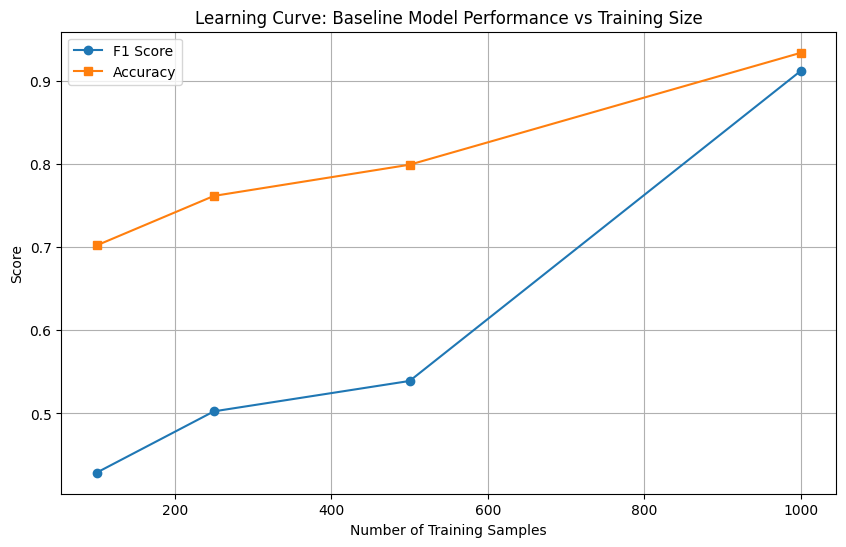

In [11]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.plot(results_df["train_size"], results_df["f1"], marker="o", label="F1 Score")
plt.plot(results_df["train_size"], results_df["accuracy"], marker="s", label="Accuracy")
plt.title("Learning Curve: Baseline Model Performance vs Training Size")
plt.xlabel("Number of Training Samples")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
results_df

,train_size,accuracy,f1
0,100,0.701987,0.428715
1,250,0.761589,0.502521
2,500,0.799117,0.539081
3,1000,0.933775,0.912213


# Weak Labeling

This notebook generates weak labels for the unlabeled data using k-Nearest Neighbors on sentence embeddings.

In [13]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"



## Initialize Weak Labeler

We use `all-mpnet-base-v2` for generating embeddings.

In [15]:
from sentence_transformers import SentenceTransformer

labeler = WeakLabeler(model_name="all-mpnet-base-v2")

## Generate and Evaluate Weak Labels

For each split size, we train a k-NN on the labeled set and predict labels for the unlabeled set. We then compare these weak labels with the true labels (which we have access to for evaluation purposes).

In [16]:
train_sizes = [100, 250, 500, 1000]
results = []

for size in train_sizes:
    print(f"\n=== Weak Labeling for {size} labeled samples ===")
    train_df = splits[f"train_{size}"]
    unlabeled_df = splits[f"unlabeled_{size}"]

    # Train k-NN
    knn = labeler.train_knn(train_df, n_neighbors=5)

    # Predict
    weak_labeled_df = labeler.predict(knn, unlabeled_df)

    # Evaluate (comparing weak labels to true labels hidden in unlabeled_df)
    # Note: unlabeled_df still has the 'label' column with true labels
    true_labels = unlabeled_df["label"]
    predicted_labels = weak_labeled_df["label"]

    acc = accuracy_score(true_labels, predicted_labels)
    f1 = f1_score(true_labels, predicted_labels, average="macro")

    print(f"Weak Label Quality (Size {size}): Accuracy={acc:.4f}, F1={f1:.4f}")

    results.append({"train_size": size, "weak_accuracy": acc, "weak_f1": f1})

    # Save weak labeled data for next step (optional, or just re-generate)
    # weak_labeled_df.to_csv(f"data/weak_labeled_{size}.csv", index=False)


=== Weak Labeling for 100 labeled samples ===


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Weak Label Quality (Size 100): Accuracy=0.8666, F1=0.8310

=== Weak Labeling for 250 labeled samples ===


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/36 [00:00<?, ?it/s]

Weak Label Quality (Size 500): Accuracy=0.8981, F1=0.8746

=== Weak Labeling for 1000 labeled samples ===


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Weak Label Quality (Size 1000): Accuracy=0.9030, F1=0.8721


## Plot Weak Label Quality

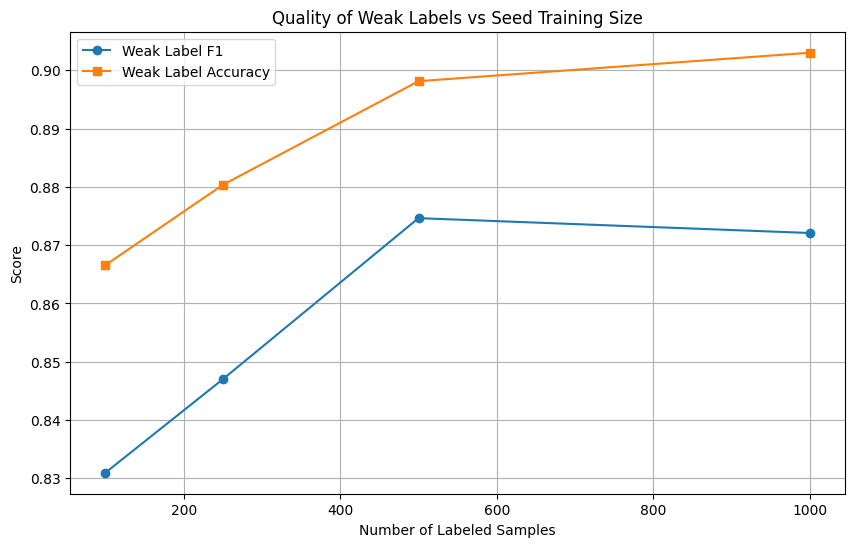

In [17]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.plot(
    results_df["train_size"], results_df["weak_f1"], marker="o", label="Weak Label F1"
)
plt.plot(
    results_df["train_size"],
    results_df["weak_accuracy"],
    marker="s",
    label="Weak Label Accuracy",
)
plt.title("Quality of Weak Labels vs Seed Training Size")
plt.xlabel("Number of Labeled Samples")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

# Semi-Supervised Training

This notebook trains the sentiment classifier on a combined dataset of hard labels (ground truth) and weak labels (generated by k-NN).

## Initialize Weak Labeler

In [19]:
from sentence_transformers import SentenceTransformer

labeler = WeakLabeler(model_name="all-mpnet-base-v2")

## Train Semi-Supervised Models

For each split size:
1. Train k-NN on labeled data.
2. Generate weak labels for unlabeled data.
3. Combine labeled and weak-labeled data.
4. Train classifier on combined data.
5. Evaluate.

In [20]:
train_sizes = [100, 250, 500, 1000]
results = []

for size in train_sizes:
    print(f"\n=== Semi-Supervised Training for {size} labeled samples ===")
    train_df = splits[f"train_{size}"]
    unlabeled_df = splits[f"unlabeled_{size}"]

    # 1. Train k-NN
    knn = labeler.train_knn(train_df, n_neighbors=5)

    # 2. Generate Weak Labels
    weak_labeled_df = labeler.predict(knn, unlabeled_df)

    # 3. Combine Data
    # We can add a flag to distinguish source if needed, but for training we just need sentence and label
    combined_df = pd.concat(
        [train_df, weak_labeled_df[["sentence", "label"]]]
    ).reset_index(drop=True)
    print(f"Combined training set size: {len(combined_df)}")

    # 4. Train Classifier
    classifier = SentimentClassifier(
        model_name="distilbert-base-uncased",
        output_dir=f"models/semi_supervised_{size}",
    )
    classifier.train(combined_df, val_df, epochs=3, batch_size=16)

    # 5. Evaluate
    metrics = classifier.evaluate(test_df)
    print(f"Results for {size} (Semi-Supervised): {metrics}")

    results.append(
        {
            "train_size": size,
            "accuracy": metrics["eval_accuracy"],
            "f1": metrics["eval_f1"],
        }
    )


=== Semi-Supervised Training for 100 labeled samples ===


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Combined training set size: 1629


Map:   0%|          | 0/1629 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/182 [00:00<?, ? examples/s]

Using device: mps
{'loss': 0.9916, 'grad_norm': 2.6569180488586426, 'learning_rate': 1.9411764705882355e-05, 'epoch': 0.09803921568627451}
{'loss': 0.8092, 'grad_norm': 4.148468017578125, 'learning_rate': 1.8758169934640523e-05, 'epoch': 0.19607843137254902}
{'loss': 0.7078, 'grad_norm': 2.3368136882781982, 'learning_rate': 1.8104575163398694e-05, 'epoch': 0.29411764705882354}
{'loss': 0.6512, 'grad_norm': 2.22763729095459, 'learning_rate': 1.7450980392156866e-05, 'epoch': 0.39215686274509803}
{'loss': 0.5025, 'grad_norm': 4.002499103546143, 'learning_rate': 1.6797385620915034e-05, 'epoch': 0.49019607843137253}
{'loss': 0.5003, 'grad_norm': 3.2227699756622314, 'learning_rate': 1.6143790849673205e-05, 'epoch': 0.5882352941176471}
{'loss': 0.4691, 'grad_norm': 2.904367208480835, 'learning_rate': 1.5490196078431373e-05, 'epoch': 0.6862745098039216}
{'loss': 0.3976, 'grad_norm': 3.057854175567627, 'learning_rate': 1.4836601307189545e-05, 'epoch': 0.7843137254901961}
{'loss': 0.3425, 'grad_

Map:   0%|          | 0/453 [00:00<?, ? examples/s]

/Users/stefanbinkert/Documents/FHNW_DS/NPR/NPR_MC_2/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.19273443520069122, 'eval_model_preparation_time': 0.0005, 'eval_accuracy': 0.9359823399558499, 'eval_f1': 0.9146121046814182, 'eval_precision': 0.9106347683575168, 'eval_recall': 0.919845314430078, 'eval_runtime': 13.7161, 'eval_samples_per_second': 33.027, 'eval_steps_per_second': 4.156}
Results for 1000 (Semi-Supervised): {'eval_loss': 0.19273443520069122, 'eval_model_preparation_time': 0.0005, 'eval_accuracy': 0.9359823399558499, 'eval_f1': 0.9146121046814182, 'eval_precision': 0.9106347683575168, 'eval_recall': 0.919845314430078, 'eval_runtime': 13.7161, 'eval_samples_per_second': 33.027, 'eval_steps_per_second': 4.156}


## Plot Comparison (Baseline vs Semi-Supervised)

Note: You should manually input the baseline results here or load them from a saved file for comparison.

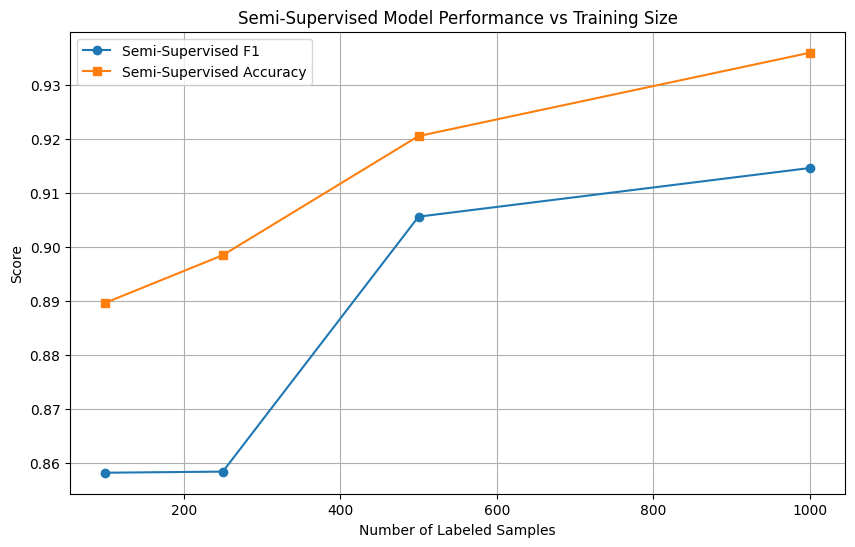

In [21]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.plot(
    results_df["train_size"], results_df["f1"], marker="o", label="Semi-Supervised F1"
)
plt.plot(
    results_df["train_size"],
    results_df["accuracy"],
    marker="s",
    label="Semi-Supervised Accuracy",
)
plt.title("Semi-Supervised Model Performance vs Training Size")
plt.xlabel("Number of Labeled Samples")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

# Bonus Analysis

This notebook covers the bonus tasks:
1.  **Embedding Visualization**: Using UMAP to visualize sentence embeddings.
2.  **LLM Few-Shot Classification**: Using GPT-4 (or similar) for sentiment analysis via prompting.

## 1. Embedding Visualization (UMAP)

Loading dataset: takala/financial_phrasebank (sentences_allagree)


Using the latest cached version of the dataset since takala/financial_phrasebank couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'sentences_allagree' at /Users/stefanbinkert/.cache/huggingface/datasets/takala___financial_phrasebank/sentences_allagree/1.0.0/550bde12e6c30e2674da973a55f57edde5181d53f5a5a34c1531c53f93b7e141 (last modified on Tue Nov 25 21:04:35 2025).


Total samples: 2264
Test size: 453
Validation size: 182
Training pool size: 1629
Created split 'train_100': 100 samples
Created split 'unlabeled_100': 1529 samples
Created split 'train_250': 250 samples
Created split 'unlabeled_250': 1379 samples
Created split 'train_500': 500 samples
Created split 'unlabeled_500': 1129 samples
Created split 'train_1000': 1000 samples
Created split 'unlabeled_1000': 629 samples


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

/Users/stefanbinkert/Documents/FHNW_DS/NPR/NPR_MC_2/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


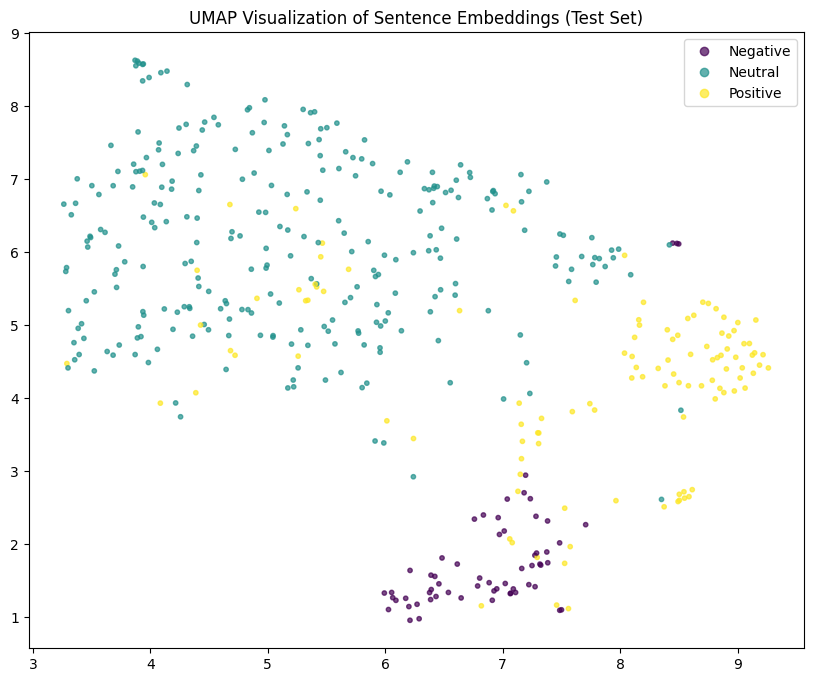

In [22]:
import matplotlib.pyplot as plt
import umap
from sentence_transformers import SentenceTransformer

splits = load_and_split_data()
test_df = splits["test"]

# Generate embeddings for test set
model = SentenceTransformer("all-mpnet-base-v2")
embeddings = model.encode(test_df["sentence"].tolist(), show_progress_bar=True)

# Reduce dimensionality with UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=test_df["label"],
    cmap="viridis",
    s=10,
    alpha=0.7,
)
plt.legend(
    handles=scatter.legend_elements()[0], labels=["Negative", "Neutral", "Positive"]
)
plt.title("UMAP Visualization of Sentence Embeddings (Test Set)")
plt.show()

## 2. LLM Few-Shot Classification

**Note**: This requires an OpenAI API key. Please set `OPENAI_API_KEY` environment variable.

In [23]:
import openai

# Ensure test_df is loaded if this cell is run independently
if 'test_df' not in locals():
    print("test_df not found. Loading data...")
    splits = load_and_split_data()
    test_df = splits['test']
    print("Data loaded.")


def normalize_llm_label(text):
    cleaned = text.strip().splitlines()[0].strip().strip(".:").lower()
    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    return label_map.get(cleaned)


api_key = os.getenv("OPENAI_API_KEY")

if api_key:
    client = openai.OpenAI(api_key=api_key)
    
    def classify_with_llm(sentence):
        prompt = f"""
        You are a financial sentiment analysis assistant.
        Classify the sentiment of the following financial news sentence as Positive, Negative, or Neutral.
        Provide the label only.
        
        Examples:
        Sentence: "The company's profits surged by 50% this quarter."
        Sentiment: Positive
        
        Sentence: "The CEO resigned amidst a major scandal."
        Sentiment: Negative
        
        Sentence: "The company announced a new product line."
        Sentiment: Neutral
        
        Sentence: "{sentence}"
        Sentiment:
        """
        
        response = client.responses.create(
            model="gpt-5.1",
            reasoning={"effort": "none"},
            input=prompt
        )
        return response.output_text

    # Run on a small subset of test data
    subset_test = test_df.head(20).copy()
    subset_test['llm_pred'] = subset_test['sentence'].apply(classify_with_llm)
    
    subset_test['llm_pred_int'] = subset_test['llm_pred'].apply(normalize_llm_label)
    valid_predictions = subset_test.dropna(subset=['llm_pred_int']).copy()
    
    if valid_predictions.empty:
        print("No valid LLM labels were returned.")
    else:
        acc = accuracy_score(valid_predictions['label'], valid_predictions['llm_pred_int'])
        print(f"LLM Few-Shot Accuracy (on {len(valid_predictions)} valid samples): {acc:.4f}")
    
else:
    print("OPENAI_API_KEY not found. Skipping LLM classification.")

LLM Few-Shot Accuracy (on 20 valid samples): 0.9500
